Model Accuracy: 95.00%

Enter Patient Details:
Age: 25
BMI: 65
Standing hours per day: 6
Family history (0 = No, 1 = Yes): 1
Pregnancy history (0 = No, 1 = Yes): 0
Smoking (0 = No, 1 = Yes): 0

Predicted Probability:
Low Risk: 68.00%
High Risk: 32.00%


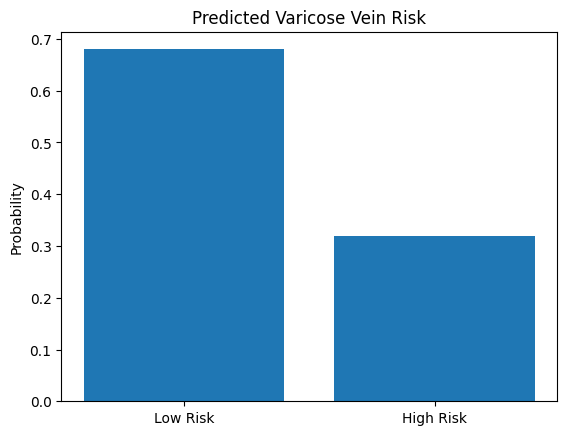

In [3]:
# ==========================================
# Varicose Vein Risk Prediction using ML
# With User Input
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -------------------------------
# Step 1: Generate Synthetic Dataset
# -------------------------------

np.random.seed(42)
n = 500

data = pd.DataFrame({
    "Age": np.random.randint(20, 70, n),
    "BMI": np.random.randint(18, 35, n),
    "Standing_Hours": np.random.randint(1, 12, n),
    "Family_History": np.random.randint(0, 2, n),
    "Pregnancy": np.random.randint(0, 2, n),
    "Smoking": np.random.randint(0, 2, n)
})

# Risk Logic
data["Risk"] = (
    (data["Age"] > 45).astype(int) +
    (data["BMI"] > 28).astype(int) +
    (data["Standing_Hours"] > 6).astype(int) +
    data["Family_History"] +
    data["Pregnancy"]
)

data["Risk"] = (data["Risk"] > 2).astype(int)

# -------------------------------
# Step 2: Train Model
# -------------------------------

X = data.drop("Risk", axis=1)
y = data["Risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
accuracy = accuracy_score(y_test, model.predict(X_test))
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

# -------------------------------
# Step 3: Take User Input
# -------------------------------

print("\nEnter Patient Details:")

age = int(input("Age: "))
bmi = float(input("BMI: "))
standing_hours = int(input("Standing hours per day: "))
family_history = int(input("Family history (0 = No, 1 = Yes): "))
pregnancy = int(input("Pregnancy history (0 = No, 1 = Yes): "))
smoking = int(input("Smoking (0 = No, 1 = Yes): "))

new_patient = pd.DataFrame({
    "Age": [age],
    "BMI": [bmi],
    "Standing_Hours": [standing_hours],
    "Family_History": [family_history],
    "Pregnancy": [pregnancy],
    "Smoking": [smoking]
})

# -------------------------------
# Step 4: Predict Risk
# -------------------------------

risk_probability = model.predict_proba(new_patient)

low_risk = risk_probability[0][0]
high_risk = risk_probability[0][1]

print("\nPredicted Probability:")
print("Low Risk: {:.2f}%".format(low_risk * 100))
print("High Risk: {:.2f}%".format(high_risk * 100))

# -------------------------------
# Step 5: Visualization
# -------------------------------

plt.figure()
plt.bar(["Low Risk", "High Risk"], [low_risk, high_risk])
plt.ylabel("Probability")
plt.title("Predicted Varicose Vein Risk")
plt.show()